In [153]:
# Raw Data
#     │
#     ▼
# Combine title + text
#     │
#     ▼
# Preprocess
#     │
#     ▼
# Train-Test Split
#     │
#     ├──────────────┐
#     ▼              ▼
# X_train         X_test
#     │
#     ▼
# Train Word2Vec
# (on X_train only)
#     │
#     ▼
# Average Word2Vec
# (train)
#     │
#     ▼
# Average Word2Vec
# (test)
#     │
#     ▼
# Logistic Regression
#     │
#     ▼
# Evaluation

In [154]:
# Clean text
#         ↓
# Train-Test Split
#         ↓
# Train Word2Vec on X_train only
#         ↓
# Create train document vectors
#         ↓
# Create test document vectors
#         ↓
# Train Logistic Regression
#         ↓
# Evaluate

In [2]:
# https://www.kaggle.com/datasets/amirmotefaker/detecting-fake-news-dataset

In [4]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [5]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

### Preprocessing the data

In [8]:
# from google.colab import drive
# drive.mount('/content/drive')

In [9]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/Siddharthan Projects/ML04-news.csv"

In [11]:
news_dataset = pd.read_csv(dataset_path)
news_dataset.shape

(6335, 4)

In [42]:
df = news_dataset.copy()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [15]:
df.isnull().sum()

,0
Unnamed: 0,0
title,0
text,0
label,0


In [24]:
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [25]:
max([len(text) for text in df.text])

115372

In [43]:
df["char_len"] = df["text"].str.len()
df["char_len"].describe()

,char_len
count,6335.000000
mean,4707.250355
std,5090.956446
min,1.000000
25%,1741.500000
50%,3642.000000
75%,6192.000000
max,115372.000000


In [44]:
df["word_len"] = df["text"].str.split().str.len()
df["word_len"].describe()

,word_len
count,6335.000000
mean,776.300710
std,854.333358
min,0.000000
25%,289.000000
50%,597.000000
75%,1024.000000
max,20891.000000


In [45]:
df["word_len"].quantile([0.5, 0.9, 0.95, 0.99])

,word_len
0.50,597.00
0.90,1510.60
0.95,2023.60
0.99,3957.56


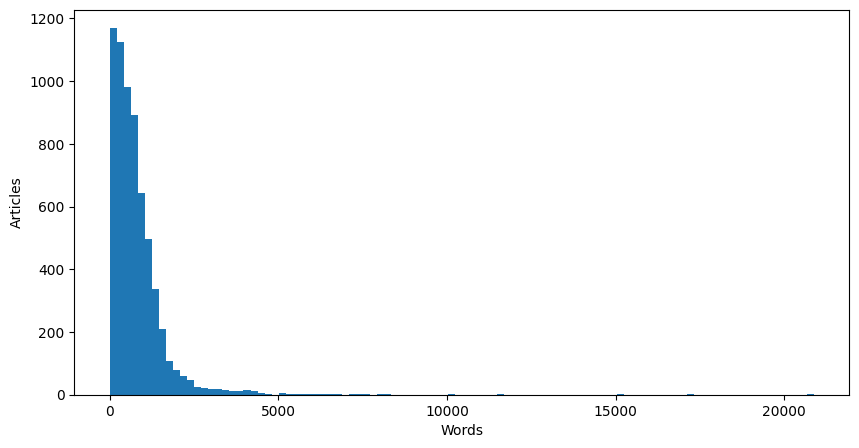

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["word_len"], bins=100)
plt.xlabel("Words")
plt.ylabel("Articles")
plt.show()

In [48]:
df.label.value_counts()

,count
label,
REAL,3171
FAKE,3164


In [49]:
df["sentence_len"] = df.text.str.count(r"\.")
df["sentence_len"].describe()

,sentence_len
count,6335.000000
mean,39.813575
std,46.445630
min,0.000000
25%,14.000000
50%,30.000000
75%,52.000000
max,1280.000000


In [50]:
df.head()

,Unnamed: 0,title,text,label,char_len,word_len,sentence_len
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,7518,1296,85
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,2646,446,28
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,2543,431,24
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,2660,404,17
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,1840,317,21


In [51]:
df.groupby("label")["word_len"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
FAKE,3164.0,679.129267,958.962790,0.0,212.0,421.0,830.0,20891.0
REAL,3171.0,873.257647,722.483569,7.0,450.5,771.0,1123.0,7602.0


In [52]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label', 'char_len', 'word_len',
       'sentence_len'],
      dtype='object')

In [53]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [54]:
df.drop(columns=["char_len", "word_len", "sentence_len"], inplace=True)

In [55]:
df.head()

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [72]:
# df["label"] = df["label"].map({ "FAKE": 0, "REAL": 1 })
df["label"] = (df["label"] == "REAL").astype(int)

In [74]:
df.label.value_counts()

,count
label,
1,3171
0,3164


In [57]:
df["content"] = df["title"] + " " + df["text"]

In [59]:
import re

def preprocess(text):
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # Remove HTML
    text = re.sub(r'<.*?>', ' ', text)
    # Remove anything inside []
    text = re.sub(r'\[.*?\]', ' ', text)
    # Keep only letters and numbers
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [60]:
df["content"] = df["content"].apply(preprocess)

In [86]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df["content"], df["label"], test_size=0.2, random_state=42)

In [142]:
tokenized_corpus = [doc.split() for doc in X_train.tolist()]

In [145]:
type(tokenized_corpus)

list

In [90]:
!pip install gensim

In [91]:
import gensim
print(gensim.__version__)

4.4.0


In [92]:
from gensim.models import Word2Vec

w2v = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4
)

In [94]:
print(w2v)

Word2Vec<vocab=40136, vector_size=300, alpha=0.025>


In [95]:
len(w2v.wv), len(w2v.wv.index_to_key)

(40136, 40136)

In [96]:
w2v.wv["trump"].shape

(300,)

In [97]:
w2v.wv.most_similar("president")

[('versa', 0.7432458996772766),
 ('barack', 0.7018446326255798),
 ('administration', 0.6369501352310181),
 ('presidency', 0.6367861032485962),
 ('presidents', 0.5706189274787903),
 ('michelle', 0.5684892535209656),
 ('biden', 0.5637178421020508),
 ('legacy', 0.5249389410018921),
 ('cabinet', 0.48232302069664),
 ('mate', 0.481972873210907)]

In [98]:
w2v.wv.most_similar("america")

[('nation', 0.6494668126106262),
 ('country', 0.5651836395263672),
 ('humanity', 0.5402103662490845),
 ('world', 0.5387162566184998),
 ('europe', 0.5152192115783691),
 ('continent', 0.5107916593551636),
 ('fascism', 0.4986317753791809),
 ('american', 0.49330031871795654),
 ('democracy', 0.490082323551178),
 ('culture', 0.48668232560157776)]

In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf.fit(X_train)

TfidfVectorizer()

In [110]:
tfidf_vocab = tfidf.vocabulary_
len(tfidf_vocab)

60740

In [105]:
idf = tfidf.idf_
len(idf)

60740

In [111]:
tfidf_dict = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

In [117]:
len(tfidf_dict)

60740

In [118]:
# Option 01
# tfidf_dict = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_)) # Order Matches perfectly
# tfidf_dict[word]

# Option 02
# index = tfidf.vocabulary_["apple"]
# weight = tfidf.idf_[index]

In [129]:
import numpy as np

def tfidf_weighted_word2vec(document, model, tfidf_dict):
    vectors = []
    weights = []
    for word in document.split():
        if word in model.wv and word in tfidf_dict:
            vectors.append(model.wv[word] * tfidf_dict[word])
            weights.append(tfidf_dict[word])
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.sum(vectors, axis=0) / np.sum(weights)

In [130]:
X_train_vectors = np.vstack(
    X_train.apply(
        lambda doc: tfidf_weighted_word2vec(doc, w2v, tfidf_dict)
    )
)

In [134]:
X_test_vectors = np.vstack(
    X_test.apply(
        lambda doc: tfidf_weighted_word2vec(doc, w2v, tfidf_dict)
    )
)

In [135]:
X_train_vectors.shape, X_test_vectors.shape

((5068, 300), (1267, 300))

In [136]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vectors, y_train)

LogisticRegression(max_iter=1000)

In [138]:
train_pred = clf.predict(X_train_vectors)
test_pred = clf.predict(X_test_vectors)

In [141]:
from sklearn.metrics import accuracy_score, classification_report

print("Train Accuracy: ", accuracy_score(y_train, train_pred))
print(classification_report(y_train, train_pred))
print("Test Accuracy: ", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred))

Train Accuracy:  0.8958168902920284
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      2536
           1       0.91      0.88      0.89      2532

    accuracy                           0.90      5068
   macro avg       0.90      0.90      0.90      5068
weighted avg       0.90      0.90      0.90      5068

Test Accuracy:  0.8816101026045777
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       628
           1       0.88      0.88      0.88       639

    accuracy                           0.88      1267
   macro avg       0.88      0.88      0.88      1267
weighted avg       0.88      0.88      0.88      1267

